In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [50]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples= 250, noise= 0.10, random_state= 55)
X.shape, y.shape

((250, 2), (250,))

In [51]:
X

array([[ 2.07025229e+00,  3.80565962e-01],
       [ 2.14150243e-01, -2.74126428e-01],
       [-5.14356131e-01,  6.97473078e-01],
       [ 7.49701206e-01, -5.37320308e-01],
       [-1.05215020e-02,  2.16229836e-01],
       [ 7.23907180e-01, -5.36020239e-01],
       [-9.23322510e-01,  1.94578254e-01],
       [-9.30026298e-01,  3.27418619e-01],
       [ 1.72386017e+00, -4.16282930e-02],
       [ 2.01834097e-01,  3.73383653e-01],
       [-7.48074104e-01,  6.86027968e-01],
       [ 5.44711033e-01, -1.40490068e-01],
       [-7.24968488e-01,  3.73517333e-01],
       [-1.02591992e+00,  1.05824689e-01],
       [ 1.87522582e+00, -1.05176358e-01],
       [-1.30447747e+00,  7.86291193e-03],
       [ 1.99354721e+00,  2.62013635e-01],
       [ 2.71675863e-01, -3.22149760e-01],
       [-4.68384878e-01,  6.90389293e-01],
       [ 1.59970565e+00,  4.89250051e-02],
       [ 2.11634496e+00,  3.56672844e-01],
       [ 8.47625559e-01,  4.87000243e-01],
       [ 8.10780492e-01,  5.53360831e-01],
       [-6.

In [52]:
y #y will not be used in modelling

array([1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1])

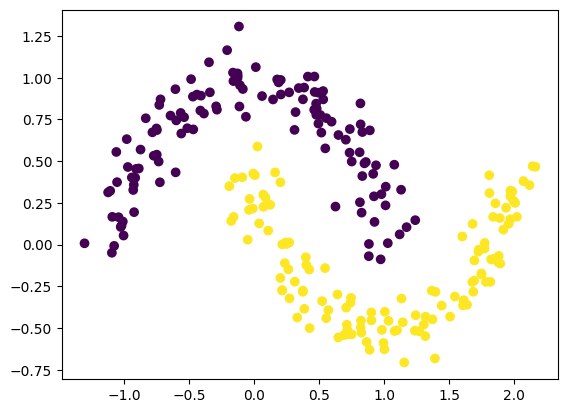

In [53]:
plt.scatter(X[:, 0], X[:, 1], c= y)
plt.show()

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.78647031,  0.28042686],
       [-0.320707  , -1.04104166],
       [-1.14775857,  0.92009029],
       [ 0.28728804, -1.57228723],
       [-0.57577013, -0.05127856],
       [ 0.25800485, -1.5696631 ],
       [-1.6120459 , -0.09498135],
       [-1.61965651,  0.17315123],
       [ 1.39322167, -0.57175414],
       [-0.33468915,  0.26592968],
       [-1.41309161,  0.89698883],
       [ 0.05456881, -0.7713024 ],
       [-1.38686049,  0.26619951],
       [-1.72852168, -0.27412662],
       [ 1.56506258, -0.70002319],
       [-2.04475976, -0.47185827],
       [ 1.69938932,  0.04113407],
       [-0.25539988, -1.1379747 ],
       [-1.09556877,  0.90579197],
       [ 1.25227275, -0.38897619],
       [ 1.83879795,  0.23219963],
       [ 0.39845864,  0.49525989],
       [ 0.35662953,  0.6292059 ],
       [-0.63600144,  1.05844491],
       [-1.8023242 , -0.15183438],
       [ 0.7183577 ,  0.17615068],
       [ 1.67299268,  0.16651545],
       [ 1.72963073, -0.15192505],
       [-1.82073884,

In [63]:
dbscan = DBSCAN(eps= 0.3)  # Change value of epsilon according to you for diff result
dbscan

DBSCAN(eps=0.3)

In [64]:
dbscan.fit(X_scaled)

DBSCAN(eps=0.3)

In [65]:
dbscan.labels_

array([ 0,  0,  1,  0,  0,  0,  1,  1,  0,  0,  1,  0,  1,  1,  0,  1,  0,
        0,  1,  0,  0,  1,  1,  1,  1,  1,  0,  0,  1,  1,  1,  0,  0,  0,
        0,  1,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,
        0,  0,  1,  1,  1,  0,  1,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,
        0,  0,  1,  1,  1,  0,  0,  1,  1,  1,  0,  1,  0,  0,  0,  1,  0,
        1,  1,  1,  0,  1,  1,  1,  1,  0,  1,  0,  0,  1,  1,  1,  1,  1,
        1,  0,  0,  1,  1,  0,  1,  1,  0,  0,  0,  1,  0,  1,  1,  1,  1,
        1, -1,  0,  1,  1,  1,  1,  1,  0,  0,  0,  1,  1,  0,  0,  1,  0,
        1,  1,  1,  0,  1,  1,  0,  1,  1,  1,  0,  1,  0,  0,  1,  1,  0,
        0,  1,  1,  1,  1,  0,  0,  0,  1,  0,  1,  0,  1,  0,  1,  1,  0,
        0,  0,  0,  0,  1,  1,  0,  0,  1,  0,  1,  0,  1,  0,  0,  1,  1,
        0,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0,  1,  0,  0,  1,  0,  1,
        1,  1,  0,  0,  1,  0,  0,  0,  1,  1,  1,  1, -1,  0,  0,  0,  1,
        0,  0,  0,  1,  1

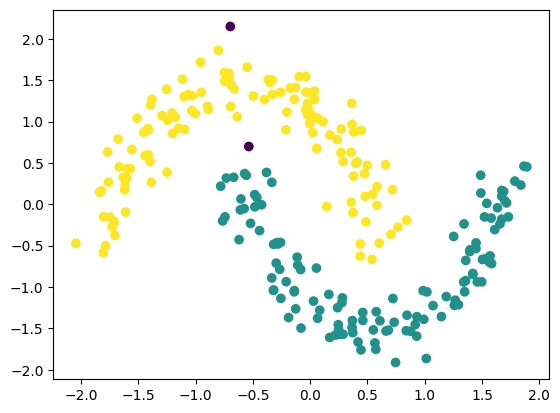

In [66]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c= dbscan.labels_)
plt.show()